In [1]:
!mamba install pandas 
import pandas as pd

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

print("Número de instâncias:", df.shape[0])
print("Número de atributos:", df.shape[1])
print("Nome das colunas:", df.columns.tolist())
print("\nTipos de dados:")
print(df.dtypes)
print("Possui dados faltantes?", df.isnull().values.any())
print("\nDados faltantes por coluna:")
print(df.isnull().sum())
print("\nPossui dados categóricos?",
      len(df.select_dtypes(include='object').columns) > 0)

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 5.078 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
Número de instâncias: 1200
Número de atributos: 13
Nome das colunas: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_p

/tmp/xpython_42/2805782319.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(df.select_dtypes(include='object').columns) > 0)



Possui dados categóricos? True


In [2]:
import pandas as pd

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

print("Número de instâncias:", df.shape[0])
print("Número de atributos:", df.shape[1])

print("\nDados faltantes por coluna:")
print(df.isnull().sum())

duplicatas = df.duplicated().sum()
print("\nNúmero de linhas duplicadas:", duplicatas)

print("\nTipos de dados:")
print(df.dtypes)

categoricas = df.select_dtypes(include=['object', 'string']).columns
print("\nColunas categóricas:", list(categoricas))

for col in categoricas:
    print(f"\nValores únicos em {col}:")
    print(df[col].value_counts().head())

Número de instâncias: 1200
Número de atributos: 13

Dados faltantes por coluna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Número de linhas duplicadas: 0

Tipos de dados:
age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.453800000011921 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                     

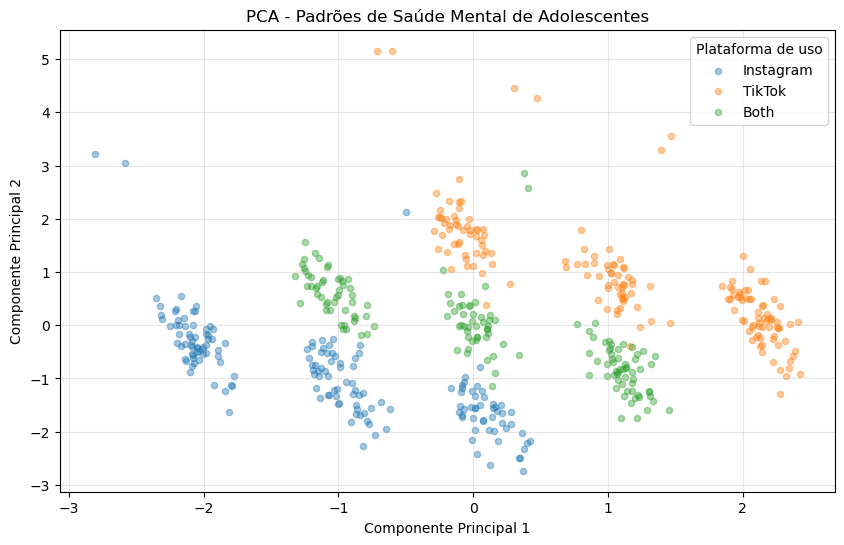


Contribuição das variáveis:
                                      PC1       PC2
daily_social_media_hours        -0.048606  0.203804
sleep_hours                      0.047156 -0.227521
screen_time_before_sleep         0.029302  0.063455
academic_performance            -0.006159 -0.032912
physical_activity               -0.065434 -0.084220
stress_level                    -0.085343  0.161217
anxiety_level                   -0.039504  0.253413
addiction_level                 -0.033136  0.065316
depression_label                -0.064553  0.403974
gender_male                      0.005511  0.006649
platform_usage_Instagram        -0.471859 -0.439214
platform_usage_TikTok            0.470760  0.453689
social_interaction_level_low     0.517690 -0.343254
social_interaction_level_medium -0.513642  0.346718


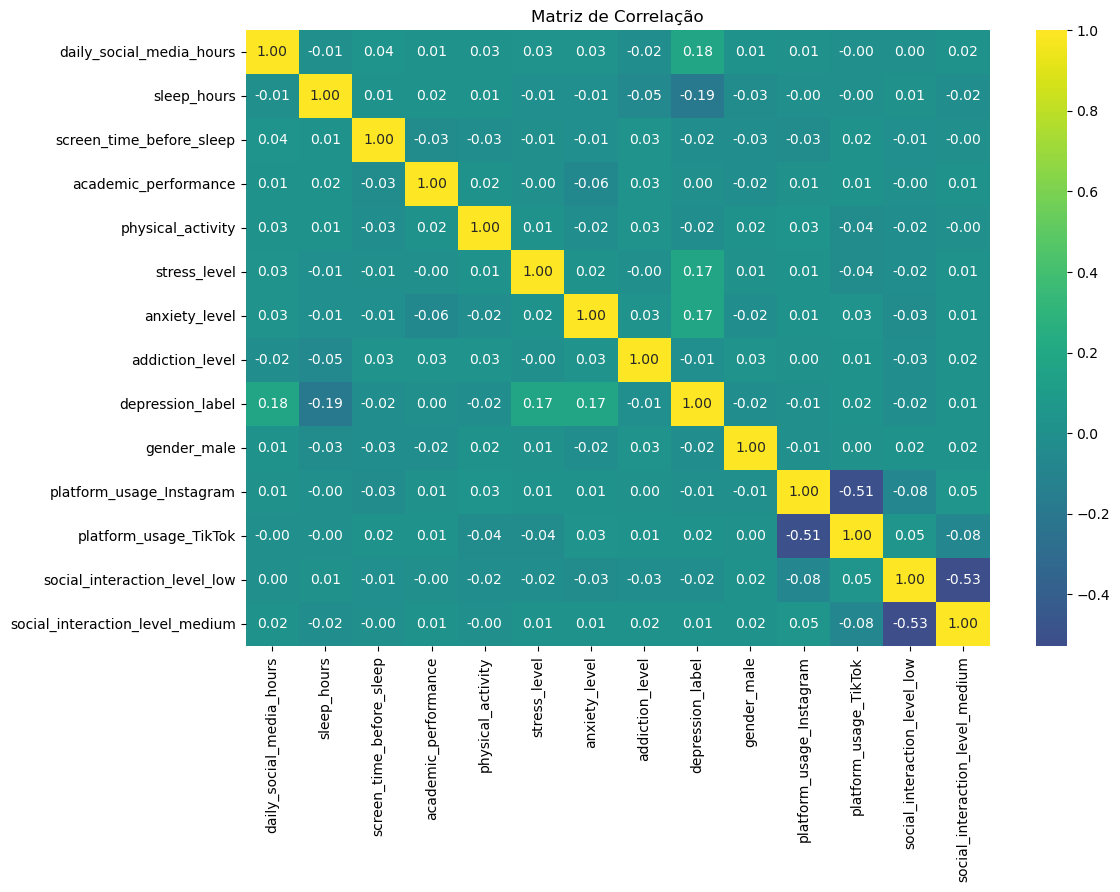

In [3]:
# -------------------------
# Instalação (se necessário)
# -------------------------
!mamba install scikit-learn seaborn

# -------------------------
# Imports
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------
# 0. Carregar dataset
# -------------------------
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# -------------------------
# 1. Selecionar colunas
# -------------------------
features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level', 'stress_level',
    'anxiety_level', 'addiction_level', 'depression_label'
]

df_model = df[[col for col in features if col in df.columns]].copy()

# -------------------------
# 2. Separar variável alvo
# -------------------------
target = 'depression_label'
groups = df_model[target]

# ⚠️ REMOVER target antes do PCA (isso estava errado no seu código)
df_model = df_model.drop(columns=[target])

# -------------------------
# 3. Variáveis categóricas
# -------------------------
df_model = pd.get_dummies(df_model, drop_first=True)

# -------------------------
# 4. Normalização
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# -------------------------
# 5. PCA
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------
# 6. DataFrame PCA
# -------------------------
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df[target] = groups.values

# -------------------------
# 7. Variância explicada
# -------------------------
print("Variância explicada por componente:")
print(pca.explained_variance_ratio_)

print("\nVariância total explicada:")
print(sum(pca.explained_variance_ratio_))

# -------------------------
# 8. Amostra
# -------------------------
sample_df = pca_df.sample(min(1000, len(pca_df)), random_state=42)

# -------------------------
# 9. Gráfico PCA
# -------------------------
df_model = df[['daily_social_media_hours', 'sleep_hours',
               'screen_time_before_sleep', 'academic_performance',
               'physical_activity', 'stress_level', 'anxiety_level',
               'addiction_level', 'depression_label', 'gender',
               'platform_usage', 'social_interaction_level']].copy()

platforms = df_model['platform_usage']
df_model = pd.get_dummies(df_model, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['platform_usage'] = platforms.values

print("Variância explicada por componente:")
print(pca.explained_variance_ratio_)
print("\nVariância total explicada:")
print(sum(pca.explained_variance_ratio_))

sample_df = pca_df.sample(min(500, len(pca_df)), random_state=42)

plt.figure(figsize=(10, 6))
for platform in sample_df['platform_usage'].unique():
    subset = sample_df[sample_df['platform_usage'] == platform]
    plt.scatter(subset['PC1'], subset['PC2'], alpha=0.4, s=20, label=platform)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA - Padrões de Saúde Mental de Adolescentes")
plt.legend(title="Plataforma de uso")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 10. Loadings
# -------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_model.columns
)

print("\nContribuição das variáveis:")
print(loadings)

# -------------------------
# 11. Matriz de correlação
# -------------------------
corr_matrix = df_model.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='viridis', center=0)
plt.title('Matriz de Correlação')
plt.show()

,Classes (Horas/dia),Freq. Absoluta (Fi),Freq. Relativa (%),Freq. Acumulada (Fac),Freq. Relativa Acumulada (%)
0,"[0, 2)",151,12.58%,151,12.580000
1,"[2, 4)",351,29.25%,502,41.830000
2,"[4, 6)",347,28.92%,849,70.750000
3,"[6, 8)",337,28.08%,1186,98.830000
4,"[8, 10)",14,1.17%,1200,100.000000
5,"[10, 12]",0,0.00%,1200,100.000000
6,TOTAL,"1,200",100.00%,—,—


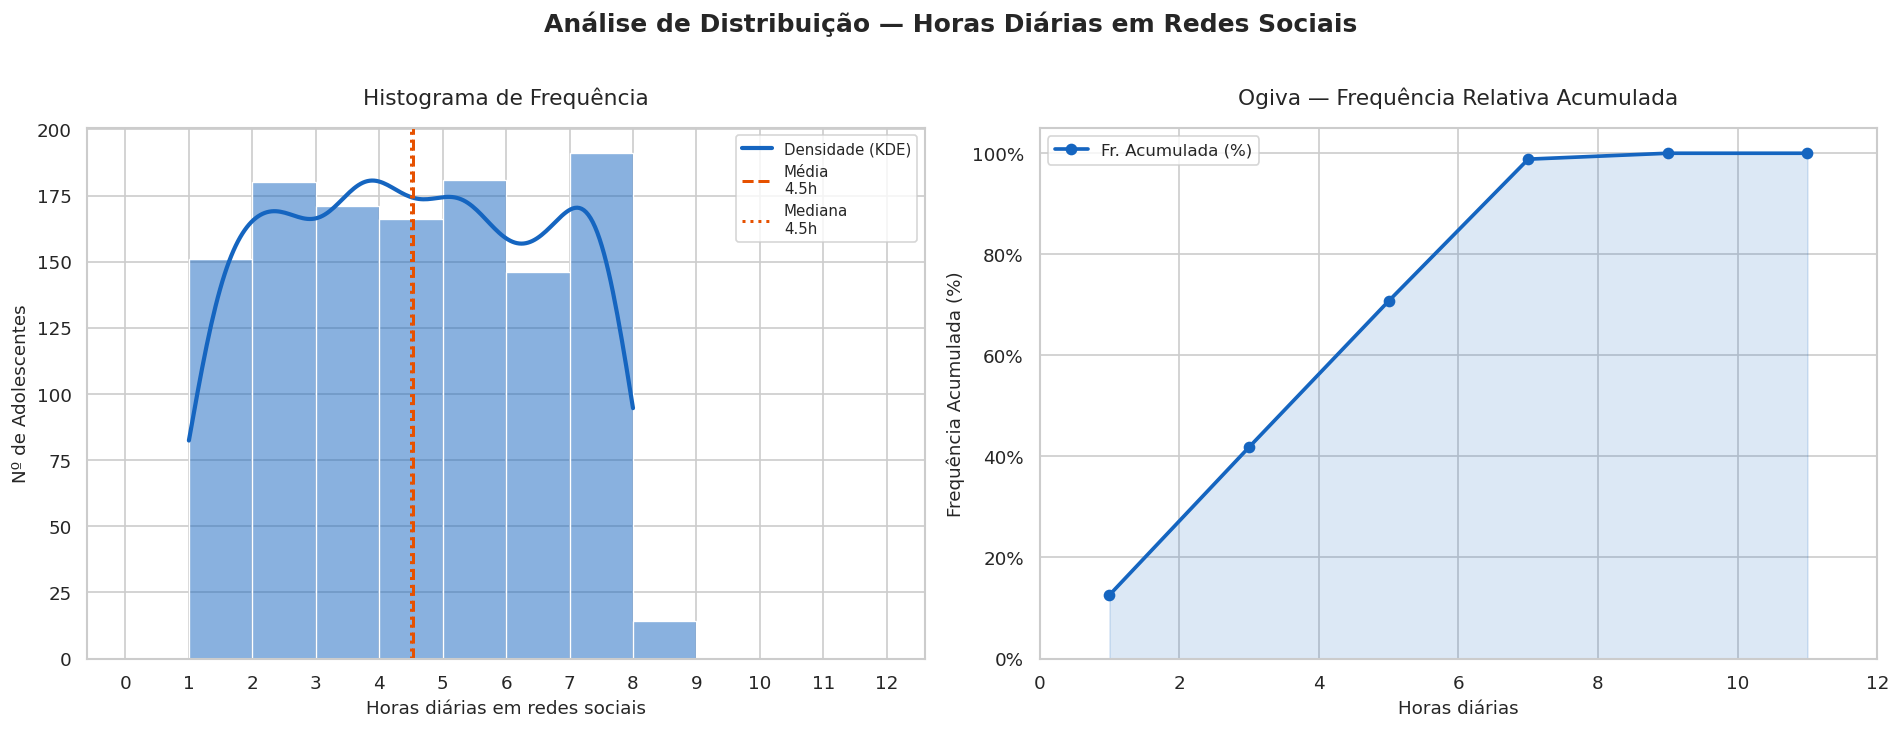


📊 Estatísticas Descritivas — Horas Diárias em Redes Sociais
────────────────────────────────────────
  Contagem              :  1200.00
  Média                 :     4.54
  Desvio Padrão         :     2.03
  Mínimo                :     1.00
  Q1 (25%)              :     2.80
  Mediana (50%)         :     4.50
  Q3 (75%)              :     6.30
  Máximo                :     8.00
  Assimetria            :   0.0092
  Curtose               :  -1.1880


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Carregar o dataset
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titlepad": 14,
})

COLUNA = "daily_social_media_hours"
INTERVALOS = list(range(0, 13, 2))
LABELS = [f"[{i}, {i+2})" if i < 10 else f"[{i}, {i+2}]"
          for i in range(0, 12, 2)]
COR_PRINCIPAL = "#1565c0"
COR_KDE       = "#e65100"

# ============================================================
# VERIFICAÇÃO DEFENSIVA
# ============================================================
if COLUNA not in df.columns:
    raise KeyError(f"Coluna '{COLUNA}' não encontrada no DataFrame.")

if df[COLUNA].isnull().any():
    n_nulos = df[COLUNA].isnull().sum()
    print(f"⚠️  Atenção: {n_nulos} valor(es) nulo(s) encontrado(s) e ignorado(s).\n")

# ============================================================
# 1. CLASSIFICAÇÃO POR FAIXAS DE HORAS
# ============================================================
df["classe_horas"] = pd.cut(
    df[COLUNA],
    bins=INTERVALOS,
    labels=LABELS,
    right=False,
    include_lowest=True,
)

# ============================================================
# 2. TABELA DE FREQUÊNCIA COMPLETA
# ============================================================
fi   = df["classe_horas"].value_counts().sort_index()
fr   = (fi / fi.sum() * 100).round(2)
fac  = fi.cumsum()
frc  = fr.cumsum().round(2)

tabela = pd.DataFrame({
    "Classes (Horas/dia)"          : fi.index,
    "Freq. Absoluta (Fi)"          : fi.values,
    "Freq. Relativa (%)"           : fr.values,
    "Freq. Acumulada (Fac)"        : fac.values,
    "Freq. Relativa Acumulada (%)" : frc.values,
})

tabela.loc[len(tabela)] = [
    "TOTAL",
    fi.sum(),
    round(fr.sum(), 2),
    "—",
    "—",
]

styled = (
    tabela.style
    .set_caption("Tabela 1 — Distribuição de Frequência de Horas Diárias em Redes Sociais")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#1565c0"), ("color", "white"),
                   ("text-align", "center"), ("font-size", "12px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("font-size", "12px")]},
    ])
    .apply(lambda x: [
        "background-color: #e3f2fd; font-weight: bold;"
        if x["Classes (Horas/dia)"] == "TOTAL" else ""
        for _ in x
    ], axis=1)
    .format({
        "Freq. Absoluta (Fi)" : "{:,.0f}",
        "Freq. Relativa (%)"  : "{:.2f}%",
    }, na_rep="—")
)

print("\n")
display(styled)

# ============================================================
# 3. VISUALIZAÇÕES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Análise de Distribuição — Horas Diárias em Redes Sociais",
    fontsize=15, fontweight="bold", y=1.01
)

# ── 3A. Histograma com KDE
ax1 = axes[0]
INTERVALOS_PLOT = list(range(0, 13, 1))

sns.histplot(
    df[COLUNA],
    bins=INTERVALOS_PLOT,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white",
    linewidth=0.8,
    line_kws={"color": COR_KDE, "linewidth": 2.5, "label": "Densidade (KDE)"},
    ax=ax1,
)

ax1.set_xticks(INTERVALOS_PLOT)
ax1.set_title("Histograma de Frequência", fontsize=13)
ax1.set_xlabel("Horas diárias em redes sociais", fontsize=11)
ax1.set_ylabel("Nº de Adolescentes", fontsize=11)

media   = df[COLUNA].mean()
mediana = df[COLUNA].median()

for val, label, ls in [
    (media,   f"Média\n{media:.1f}h",     "--"),
    (mediana, f"Mediana\n{mediana:.1f}h", ":"),
]:
    ax1.axvline(val, color=COR_KDE, linestyle=ls, linewidth=1.8, label=label)

ax1.legend(fontsize=9)

# ── 3B. Ogiva
ax2 = axes[1]
midpoints = [(INTERVALOS[i] + INTERVALOS[i+1]) / 2 for i in range(len(INTERVALOS)-1)]
ax2.plot(midpoints, frc.values, marker="o", color=COR_PRINCIPAL,
         linewidth=2.2, markersize=6, label="Fr. Acumulada (%)")
ax2.fill_between(midpoints, frc.values, alpha=0.15, color=COR_PRINCIPAL)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_xticks(INTERVALOS)
ax2.set_title("Ogiva — Frequência Relativa Acumulada", fontsize=13)
ax2.set_xlabel("Horas diárias", fontsize=11)
ax2.set_ylabel("Frequência Acumulada (%)", fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================
# 4. ESTATÍSTICAS DESCRITIVAS RESUMIDAS
# ============================================================
stats = df[COLUNA].describe().rename({
    "count": "Contagem", "mean": "Média", "std": "Desvio Padrão",
    "min": "Mínimo", "25%": "Q1 (25%)", "50%": "Mediana (50%)",
    "75%": "Q3 (75%)", "max": "Máximo",
})

print("\n📊 Estatísticas Descritivas — Horas Diárias em Redes Sociais")
print("─" * 40)
for nome, valor in stats.items():
    print(f"  {nome:<22}: {valor:>8.2f}")
print(f"  {'Assimetria':<22}: {df[COLUNA].skew():>8.4f}")
print(f"  {'Curtose':<22}: {df[COLUNA].kurt():>8.4f}")

/tmp/xpython_42/2787456845.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="depression_label", data=df, palette=["#1565c0", "#e65100"], ax=axes[1])


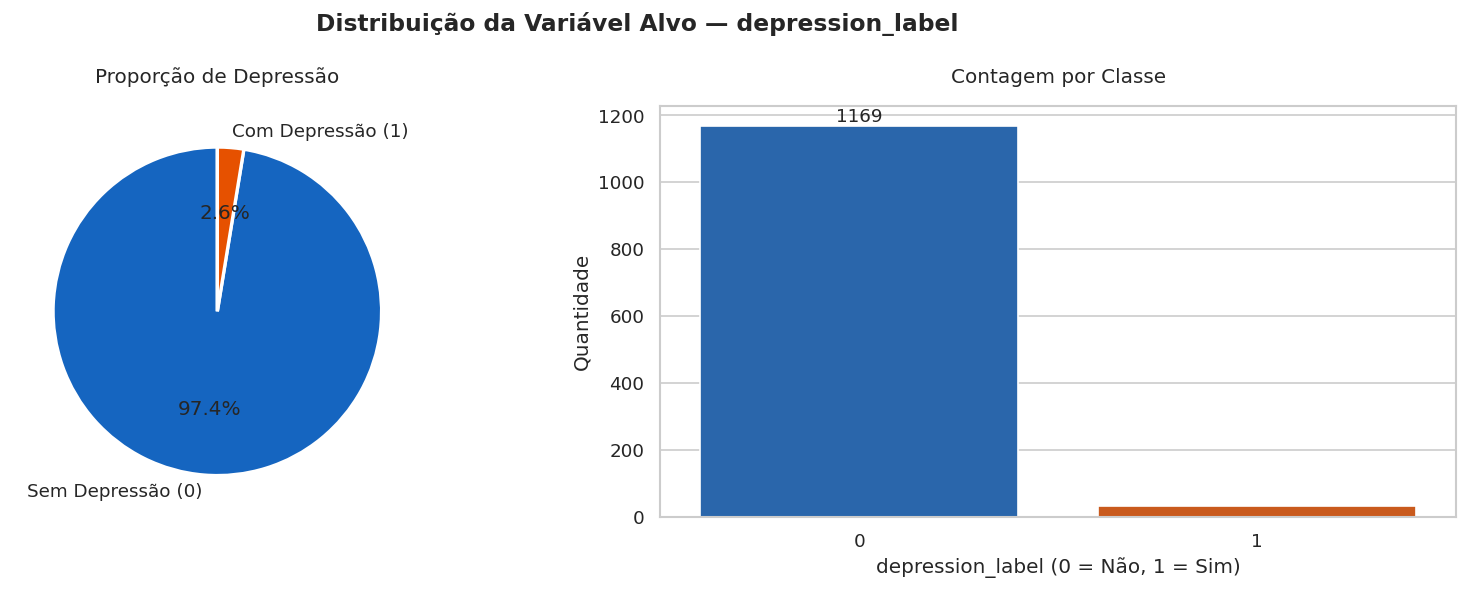

Distribuição:
depression_label
0    1169
1      31
Name: count, dtype: int64

Balanceamento: 97.4% vs 2.6%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuição da Variável Alvo — depression_label", fontsize=14, fontweight="bold")

contagem = df["depression_label"].value_counts()
labels = ["Sem Depressão (0)", "Com Depressão (1)"]
cores = ["#1565c0", "#e65100"]

axes[0].pie(
    contagem,
    labels=labels,
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Proporção de Depressão", fontsize=12)

sns.countplot(x="depression_label", data=df, palette=["#1565c0", "#e65100"], ax=axes[1])
axes[1].set_title("Contagem por Classe", fontsize=12)
axes[1].set_xlabel("depression_label (0 = Não, 1 = Sim)")
axes[1].set_ylabel("Quantidade")
axes[1].bar_label(axes[1].containers[0], fontsize=11)

plt.tight_layout()
plt.show()

print("Distribuição:")
print(df["depression_label"].value_counts())
print(f"\nBalanceamento: {contagem[0]/len(df)*100:.1f}% vs {contagem[1]/len(df)*100:.1f}%")

/tmp/xpython_42/3914690616.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/xpython_42/3914690616.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/xpython_42/3914690616.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/xpython_42/3914690616.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/xpython_42/3914690616.py:16: FutureWarning: 

Passing `palette` wit

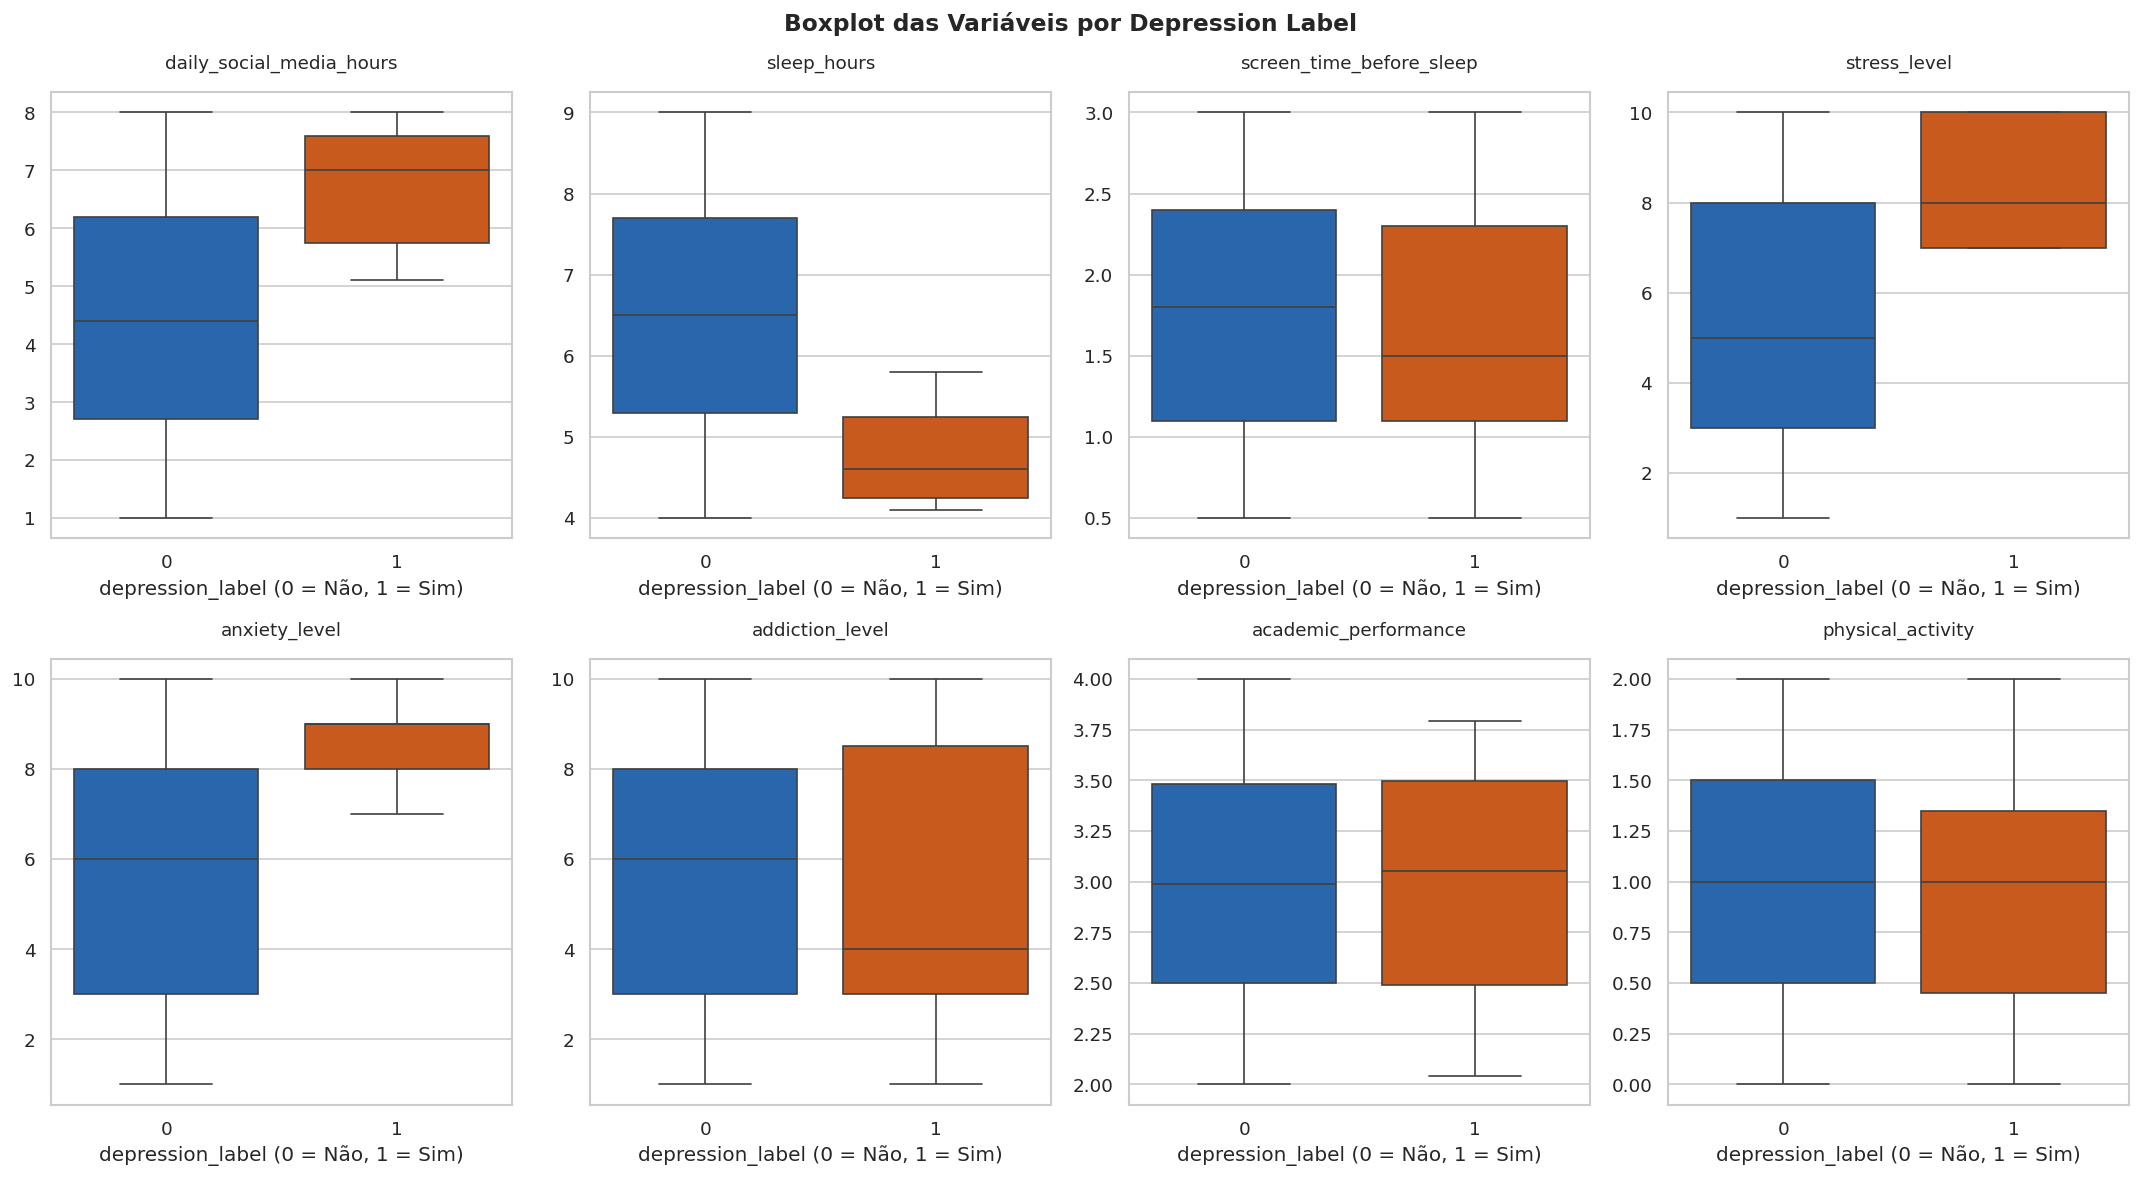

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
sns.set_theme(style="whitegrid", palette="muted")

cols = ["daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
        "stress_level", "anxiety_level", "addiction_level", "academic_performance", "physical_activity"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Boxplot das Variáveis por Depression Label", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        x="depression_label", y=col, data=df,
        palette=["#1565c0", "#e65100"], ax=axes[i]
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("depression_label (0 = Não, 1 = Sim)")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

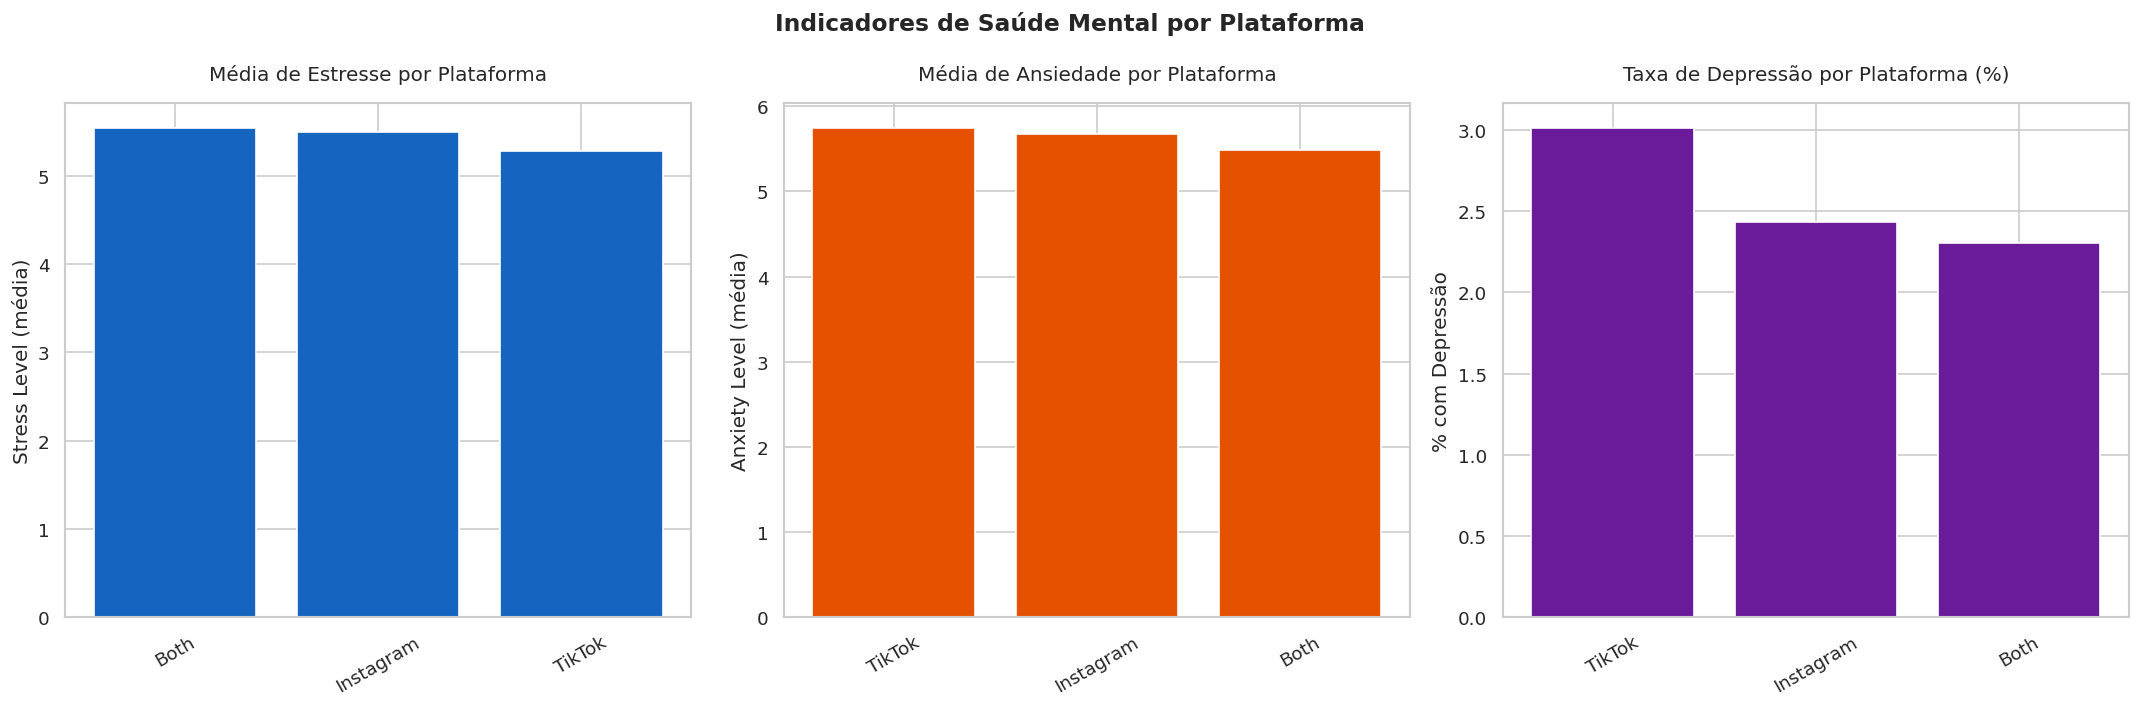

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Indicadores de Saúde Mental por Plataforma", fontsize=14, fontweight="bold")

media_stress = df.groupby("platform_usage")["stress_level"].mean().sort_values(ascending=False)
axes[0].bar(media_stress.index, media_stress.values, color="#1565c0", edgecolor="white")
axes[0].set_title("Média de Estresse por Plataforma")
axes[0].set_ylabel("Stress Level (média)")
axes[0].tick_params(axis="x", rotation=30)

media_anx = df.groupby("platform_usage")["anxiety_level"].mean().sort_values(ascending=False)
axes[1].bar(media_anx.index, media_anx.values, color="#e65100", edgecolor="white")
axes[1].set_title("Média de Ansiedade por Plataforma")
axes[1].set_ylabel("Anxiety Level (média)")
axes[1].tick_params(axis="x", rotation=30)

taxa_dep = df.groupby("platform_usage")["depression_label"].mean().sort_values(ascending=False) * 100
axes[2].bar(taxa_dep.index, taxa_dep.values, color="#6a1b9a", edgecolor="white")
axes[2].set_title("Taxa de Depressão por Plataforma (%)")
axes[2].set_ylabel("% com Depressão")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

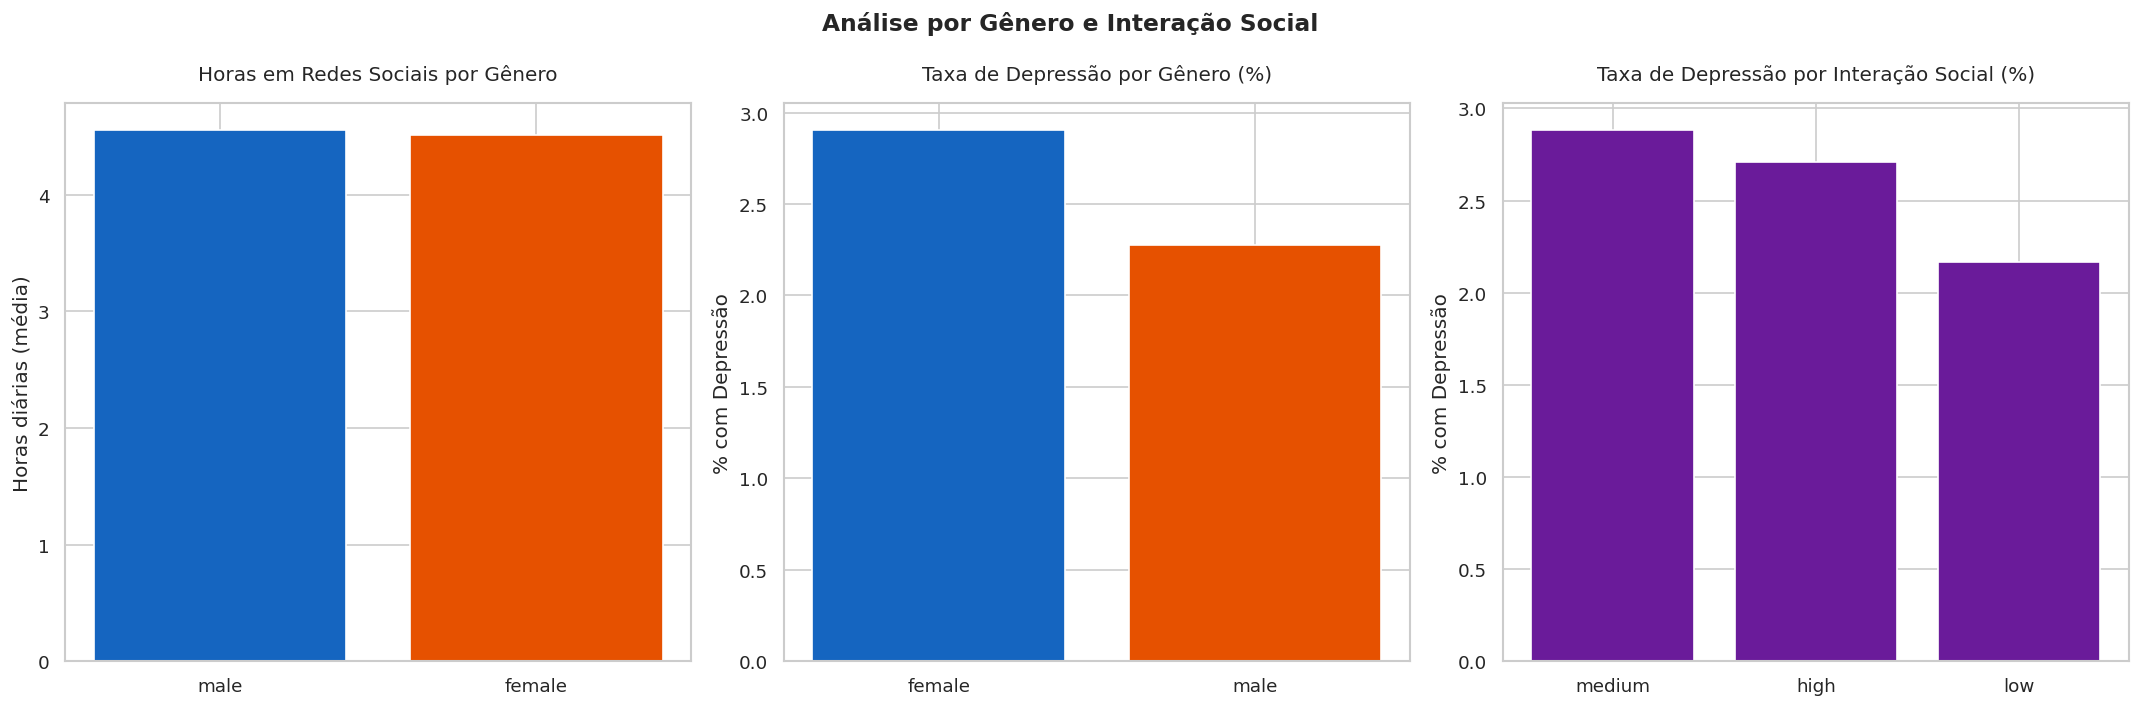

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análise por Gênero e Interação Social", fontsize=14, fontweight="bold")

media_gen = df.groupby("gender")["daily_social_media_hours"].mean().sort_values(ascending=False)
axes[0].bar(media_gen.index, media_gen.values, color=["#1565c0", "#e65100"], edgecolor="white")
axes[0].set_title("Horas em Redes Sociais por Gênero")
axes[0].set_ylabel("Horas diárias (média)")

taxa_gen = df.groupby("gender")["depression_label"].mean() * 100
axes[1].bar(taxa_gen.index, taxa_gen.values, color=["#1565c0", "#e65100"], edgecolor="white")
axes[1].set_title("Taxa de Depressão por Gênero (%)")
axes[1].set_ylabel("% com Depressão")

taxa_int = df.groupby("social_interaction_level")["depression_label"].mean().sort_values(ascending=False) * 100
axes[2].bar(taxa_int.index, taxa_int.values, color="#6a1b9a", edgecolor="white")
axes[2].set_title("Taxa de Depressão por Interação Social (%)")
axes[2].set_ylabel("% com Depressão")

plt.tight_layout()
plt.show()

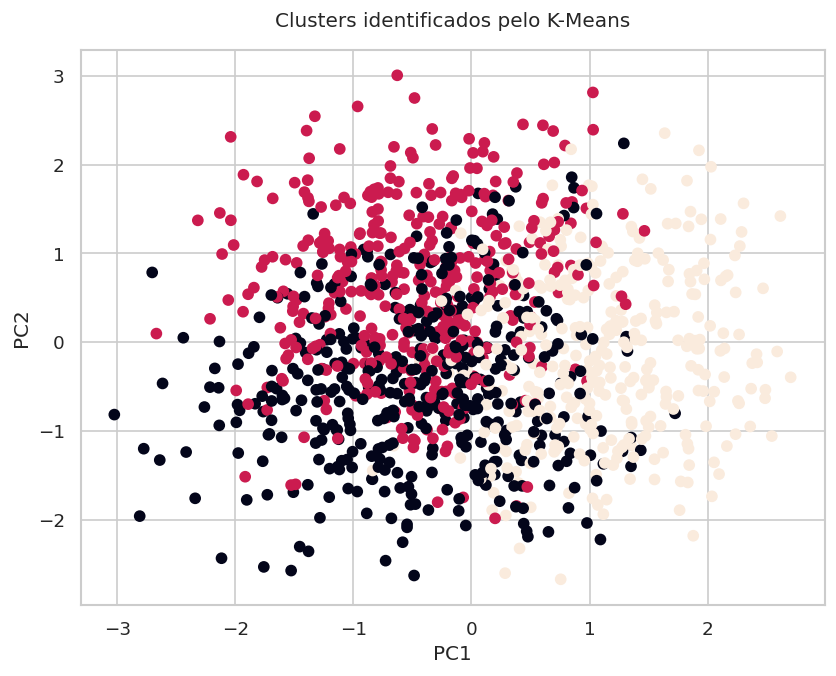

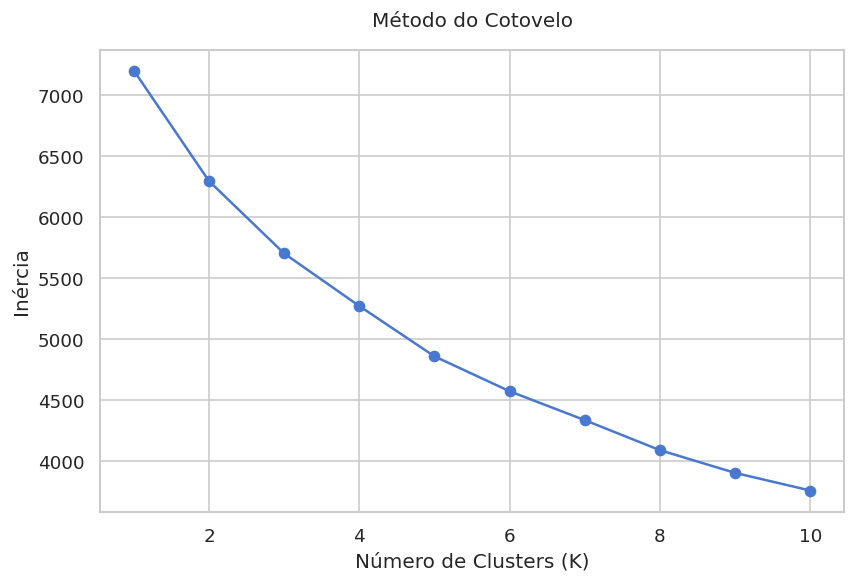

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


from sklearn.decomposition import PCA
import pandas as pd

# Aplicando PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

# Criando dataframe com os componentes principais
df_pca = pd.DataFrame(
    data=pca_components,
    columns=['PC1', 'PC2']
)
# Selecionar variáveis numéricas
features = df[[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'physical_activity',
    'academic_performance'
]]

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Aplicação do K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar clusters ao dataframe
df['cluster'] = clusters

# Visualização utilizando PCA
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters identificados pelo K-Means')
plt.show()

inertia = []
K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

# Árvore de Decisão (Decision Tree)

## O que é?

A Árvore de Decisão é um algoritmo de aprendizado supervisionado utilizado para:

- Classificação
- Regressão

Ela funciona criando perguntas e dividindo os dados em grupos até chegar em uma decisão final.

---

# Como funciona?

A árvore analisa os dados e cria regras do tipo:

```text
Se stress_level <= 6
    então → Sem depressão
Senão
    então → Depressão

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Variáveis de entrada
X = df[[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'physical_activity'
]]

# Variável alvo
y = df['depression_label']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Modelo de árvore de decisão
model = DecisionTreeClassifier(random_state=42)

# Treinamento
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Acurácia: 0.9972222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      0.89      0.94         9

    accuracy                           1.00       360
   macro avg       1.00      0.94      0.97       360
weighted avg       1.00      1.00      1.00       360



Conclusão do seu resultado

Seu modelo está muito bom porque:

✅ acertou quase tudo
✅ não teve falsos positivos
✅ teve recall alto
✅ F1-score alto

Mas você deve observar:

⚠️ há poucos exemplos da classe 1
⚠️ o dataset está desbalanceado
⚠️ a acurácia sozinha pode enganar

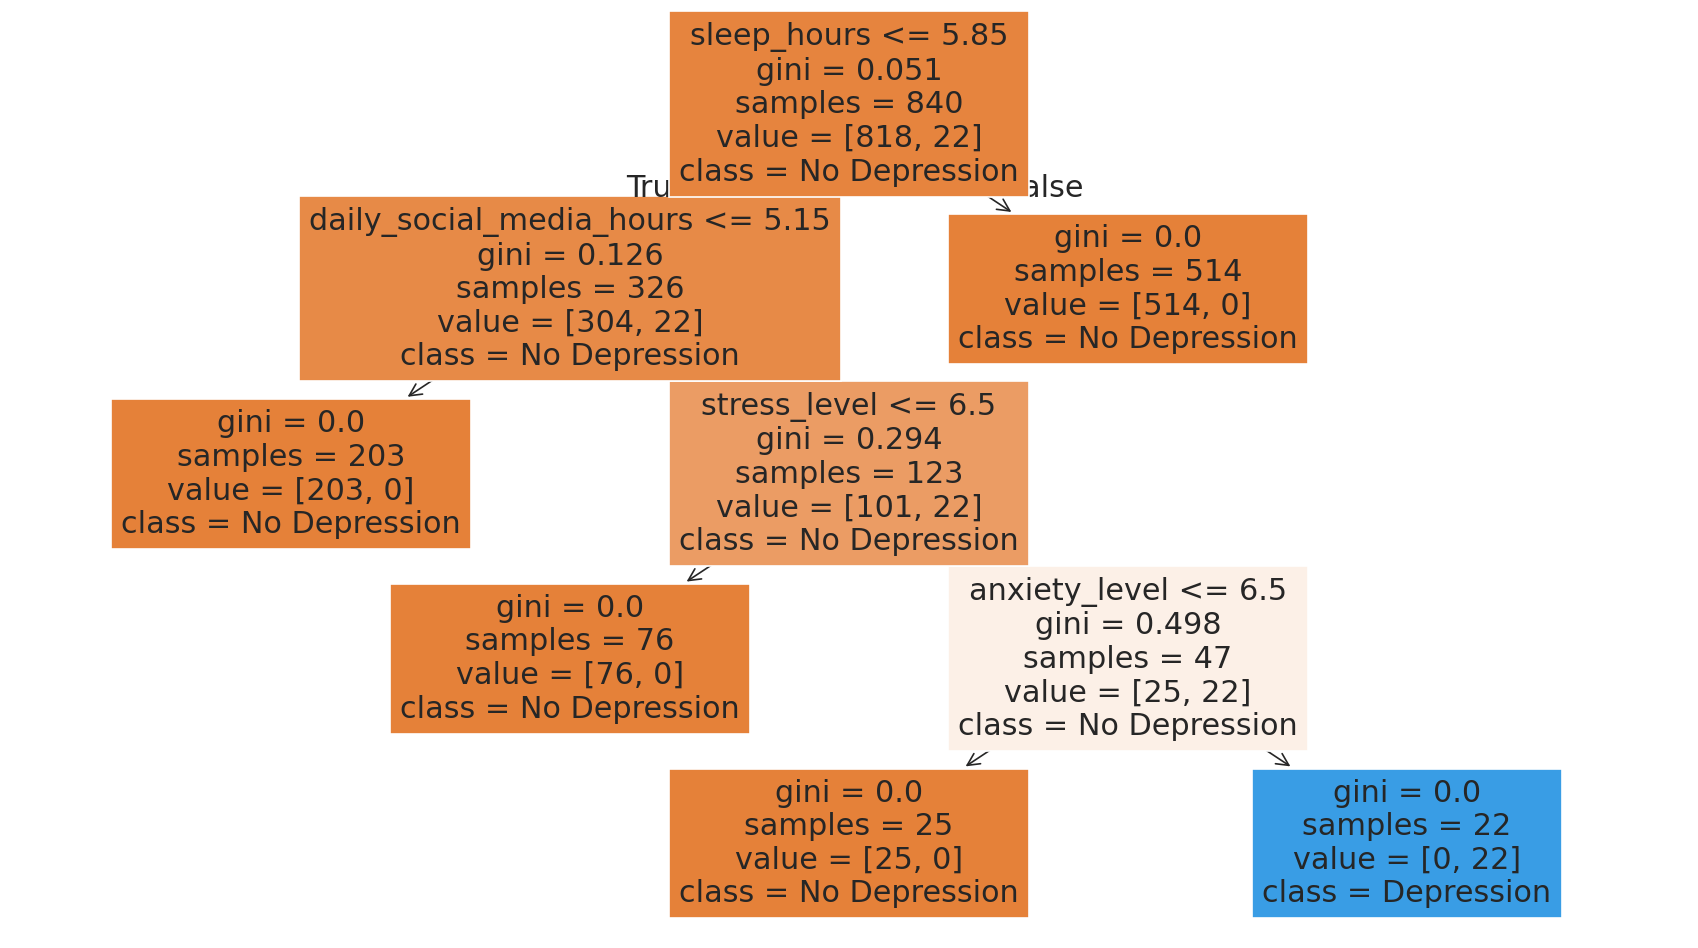

In [14]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No Depression', 'Depression']
)

plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Variáveis de entrada
X = df[[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'physical_activity'
]]

# Variável alvo
y = df['depression_label']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo K-NN
knn = KNeighborsClassifier(n_neighbors=5)

# Treinamento
knn.fit(X_train_scaled, y_train)

# Previsões
y_pred = knn.predict(X_test_scaled)

# Acurácia
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9805555555555555


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5
)

print("Scores:", scores)

print("Média da Validação Cruzada:", scores.mean())

Scores: [0.99404762 0.98809524 0.99404762 0.99404762 0.98214286]
Média da Validação Cruzada: 0.9904761904761905


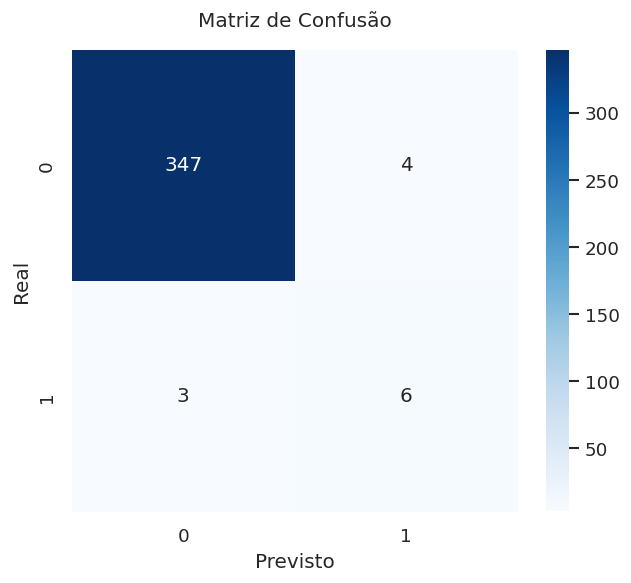

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',\
    cmap='Blues'
)

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       351
           1       0.60      0.67      0.63         9

    accuracy                           0.98       360
   macro avg       0.80      0.83      0.81       360
weighted avg       0.98      0.98      0.98       360

